# M1-B1 — Réentraînement Pyrenex Crédit

Objectif : réentraîner un modèle de scoring du risque de défaut à partir du nouveau dataset Lending Club préparé, comparer au modèle historique Pyrenex-risk-v1, puis décider si le modèle v2 doit remplacer la baseline 2017.

Règle importante : le fichier `lending_club_holdout.csv` n'est utilisé qu'à l'évaluation finale. Toutes les expérimentations intermédiaires utilisent uniquement `lending_club_train.csv`.

## 1. Baseline 2017 — Pyrenex-risk-v1

Le modèle historique Pyrenex-risk-v1 est un `RandomForestClassifier` entraîné en 2017 sur environ 12 000 lignes.

Métriques rapportées sur un test split 20% de 2017 :

| Métrique | Valeur |
|---|---:|
| Accuracy | 0.8492 |
| F1 macro | 0.5018 |
| ROC-AUC | 0.7296 |
| Precision Charged Off | 0.61 |
| Recall Charged Off | 0.05 |

Features numériques utilisées :

- `loan_amnt`
- `int_rate`
- `installment`
- `annual_inc`
- `dti`
- `delinq_2yrs`
- `fico_range_low`
- `revol_util`

Features catégorielles utilisées :

- `term`
- `grade`
- `home_ownership`
- `verification_status`
- `purpose`
- `emp_length`

Lecture critique : l'accuracy est élevée, mais le modèle détecte très mal les défauts. Le recall de la classe `Charged Off` est seulement de 0.05, ce qui signifie que la majorité des vrais défauts ne sont pas identifiés. Pour ce brief, la comparaison doit donc privilégier `F1 macro`, `ROC-AUC` et la matrice de confusion plutôt que l'accuracy seule.

In [4]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

DATA_DIR = Path("../data")
TRAIN_PATH = DATA_DIR / "lending_club_train.csv"

TARGET_COLUMN = "loan_status"

NUMERIC_FEATURES = [
    "loan_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "revol_util",
]

CATEGORICAL_FEATURES = [
    "term",
    "grade",
    "home_ownership",
    "verification_status",
    "purpose",
    "emp_length",
]

TARGET_MAPPING = {
    "Fully Paid": 0,
    "Charged Off": 1,
}

In [6]:
df = pd.read_csv(TRAIN_PATH)
df.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,fico_range_low,revol_util,loan_status
0,5700,36 months,6.71,175.24,A,3 years,MORTGAGE,38900,Not Verified,small_business,17.92,0,738,78.1,Fully Paid
1,8700,36 months,11.83,288.26,C,3 years,RENT,51400,Verified,home_improvement,21.26,0,696,75.5,Fully Paid
2,7900,36 months,11.25,259.57,C,5 years,RENT,38900,Verified,debt_consolidation,13.56,0,696,8.1,Fully Paid
3,35800,36 months,9.61,1148.62,B,3 years,MORTGAGE,82900,Verified,credit_card,29.99,0,726,53.4,Fully Paid
4,16000,60 months,14.43,375.87,C,8 years,MORTGAGE,32700,Not Verified,home_improvement,17.98,1,709,74.5,Fully Paid


In [8]:
df.shape

(24000, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            24000 non-null  int64  
 1   term                 24000 non-null  object 
 2   int_rate             24000 non-null  float64
 3   installment          24000 non-null  float64
 4   grade                24000 non-null  object 
 5   emp_length           23047 non-null  object 
 6   home_ownership       24000 non-null  object 
 7   annual_inc           24000 non-null  int64  
 8   verification_status  24000 non-null  object 
 9   purpose              24000 non-null  object 
 10  dti                  24000 non-null  float64
 11  delinq_2yrs          24000 non-null  int64  
 12  fico_range_low       24000 non-null  int64  
 13  revol_util           23609 non-null  float64
 14  loan_status          24000 non-null  object 
dtypes: float64(4), int64(4), object(7)
m

In [12]:
missing_values = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

emp_length    953
revol_util    391
dtype: int64

In [14]:
target_distribution = df[TARGET_COLUMN].value_counts()
target_distribution_normalized = df[TARGET_COLUMN].value_counts(normalize=True)

display(target_distribution)
display(target_distribution_normalized)

loan_status
Fully Paid     19587
Charged Off     4413
Name: count, dtype: int64

loan_status
Fully Paid     0.816125
Charged Off    0.183875
Name: proportion, dtype: float64

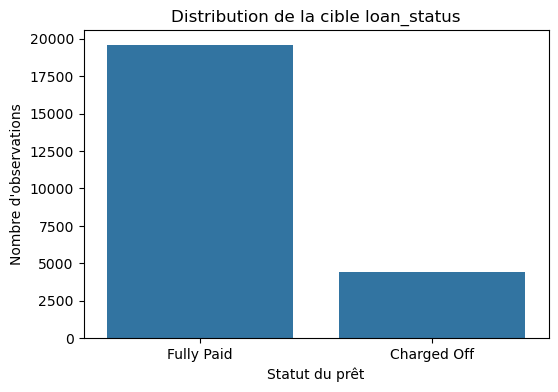

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title("Distribution de la cible loan_status")
plt.xlabel("Statut du prêt")
plt.ylabel("Nombre d'observations")
plt.show()

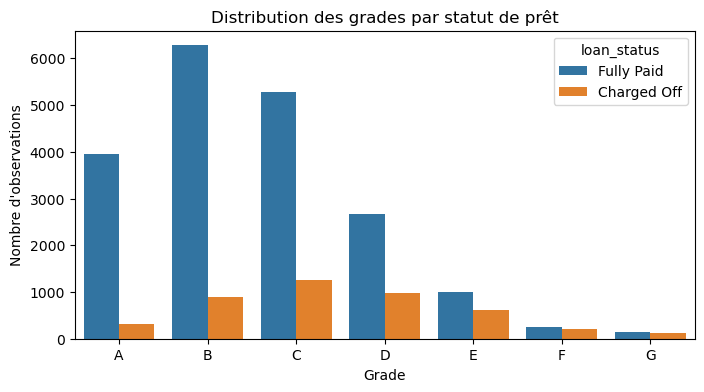

In [18]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="grade", hue=TARGET_COLUMN, order=sorted(df["grade"].dropna().unique()))
plt.title("Distribution des grades par statut de prêt")
plt.xlabel("Grade")
plt.ylabel("Nombre d'observations")
plt.show()

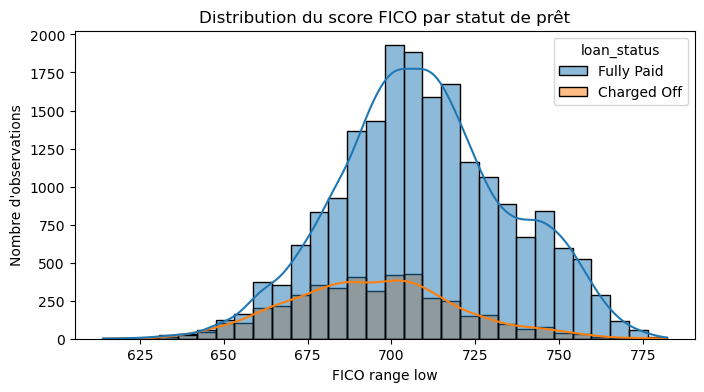

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="fico_range_low", hue=TARGET_COLUMN, bins=30, kde=True)
plt.title("Distribution du score FICO par statut de prêt")
plt.xlabel("FICO range low")
plt.ylabel("Nombre d'observations")
plt.show()

## Différences observées entre le dataset 2017 et le dataset 2025

Le dataset 2025 contient environ 24 000 lignes dans le fichier d'entraînement, contre environ 12 000 lignes pour la baseline 2017. Le schéma reste compatible avec la baseline : les mêmes variables numériques et catégorielles peuvent être utilisées, avec `loan_status` comme cible.

La proportion de défauts (`Charged Off`) est plus élevée que dans la baseline 2017, ce qui confirme un déséquilibre de classes toujours présent. Des valeurs manquantes apparaissent notamment sur `emp_length` et `revol_util`, contrairement au dataset 2017 qui n'en contenait pas. Le preprocessing v2 devra donc intégrer l'imputation dans un `Pipeline` scikit-learn pour éviter la fuite de données observée dans la démarche historique.